# AI and Economic Productivity: Myth or Measurable Reality?

**Author:** Manau Salaun
**Date:** June 2026

## Research question

Is there a statistically significant relationship between the adoption of artificial intelligence by firms and labour productivity across European countries?

This question sits at the heart of current economic debates. International institutions (OECD, IMF) publish widely varying estimates of AI's impact on productivity, without clear consensus, partly because this effect is difficult to measure at the macroeconomic level. This project proposes a simple, transparent, and reproducible empirical analysis of this relationship using official data.

## Analysis outline

1. Data presentation and limitations
2. Exploratory data analysis (EDA)
3. Hypothesis test: do countries with high AI adoption have significantly different productivity?
4. Simple regression: how strong is the link between AI adoption and productivity?
5. Multiple regression: does this link hold once we control for a country's wealth?
6. Checking the model's assumptions
7. Conclusion and limitations


## 1. Data and sources

All data used come from official sources:

| Variable | Source | Year |
|---|---|---|
| Firm-level AI adoption | Eurostat (isoc_eb_ai) | 2024 and 2025 |
| Labour productivity (GDP per hour worked) | OECD / ILO (modelled estimates) | 2025 |
| Real GDP per capita | Eurostat (sdg_08_10) | 2023 |

**Important limitations to keep in mind:**

- The three variables do not come from exactly the same year (slight time lag).
- The sample is European (EU plus a few associated countries): results cannot be generalized to the whole world.
- A correlation between AI adoption and productivity does not prove that AI *causes* productivity — causality could run the other way (richer countries have more resources to invest in AI), or be driven by a third, common factor.

This last point is precisely why GDP per capita is included as a control variable later in the analysis.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv('../data/dataset_final_en.csv')
df.head()

,country,ai_adoption_2024,ai_adoption_2025,ai_adoption_growth_pp,small_enterprises_adoption,medium_enterprises_adoption,large_enterprises_adoption,hourly_productivity,gdp_per_capita
0,Denmark,27.58,42.03,14.45,37.5,58.3,74.5,92.2,52510
1,Finland,24.37,37.82,13.45,33.5,51.4,79.4,80.5,36760
2,Sweden,25.09,35.04,9.95,30.7,49.6,71.9,83.9,44620
3,Belgium,24.71,34.54,9.83,28.8,54.5,76.4,91.5,37340
4,Luxembourg,23.73,33.61,9.88,30.5,43.7,58.0,159.5,83320


In [2]:
print(f"Number of countries in the sample: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")
df.info()

Number of countries in the sample: 31
Number of variables: 9
<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country                      31 non-null     str    
 1   ai_adoption_2024             31 non-null     float64
 2   ai_adoption_2025             31 non-null     float64
 3   ai_adoption_growth_pp        31 non-null     float64
 4   small_enterprises_adoption   30 non-null     float64
 5   medium_enterprises_adoption  31 non-null     float64
 6   large_enterprises_adoption   30 non-null     float64
 7   hourly_productivity          31 non-null     float64
 8   gdp_per_capita               31 non-null     int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 2.3 KB


## 2. Exploratory data analysis (EDA)

Before any test or model, we need to understand the shape of our data: its distribution, missing values, and especially the visual relationship between our variables of interest.


In [3]:
df.isnull().sum()

country                        0
ai_adoption_2024               0
ai_adoption_2025               0
ai_adoption_growth_pp          0
small_enterprises_adoption     1
medium_enterprises_adoption    0
large_enterprises_adoption     1
hourly_productivity            0
gdp_per_capita                 0
dtype: int64

There is one missing value for Montenegro on small and large enterprise adoption: Eurostat flags this data as confidential in the source report. Since these two columns are not used in the main regression (we use `ai_adoption_2025`, the overall indicator), this row is kept rather than dropped.

In [4]:
df.describe().round(2)

,ai_adoption_2024,ai_adoption_2025,ai_adoption_growth_pp,small_enterprises_adoption,medium_enterprises_adoption,large_enterprises_adoption,hourly_productivity,gdp_per_capita
count,31.00,31.00,31.00,30.00,31.00,30.00,31.00,31.00
mean,13.73,19.88,6.15,17.34,28.95,51.82,68.62,28708.71
std,7.22,10.30,4.04,9.29,14.57,16.63,33.18,19739.38
min,3.07,5.21,-0.88,4.10,7.80,18.30,29.80,6500.00
25%,8.06,10.24,2.93,9.40,15.30,40.92,48.10,14950.00
50%,11.26,18.16,6.22,16.20,28.80,53.00,56.50,22130.00
75%,20.52,27.43,9.59,24.68,39.65,64.00,82.20,37050.00
max,27.58,42.03,14.45,37.50,58.30,79.40,164.70,83320.00


### 2.1. Distribution of the two main variables

We first check whether our two main variables (AI adoption and productivity) follow a roughly normal distribution, or whether they are strongly skewed — which will shape how we interpret the analyses that follow.

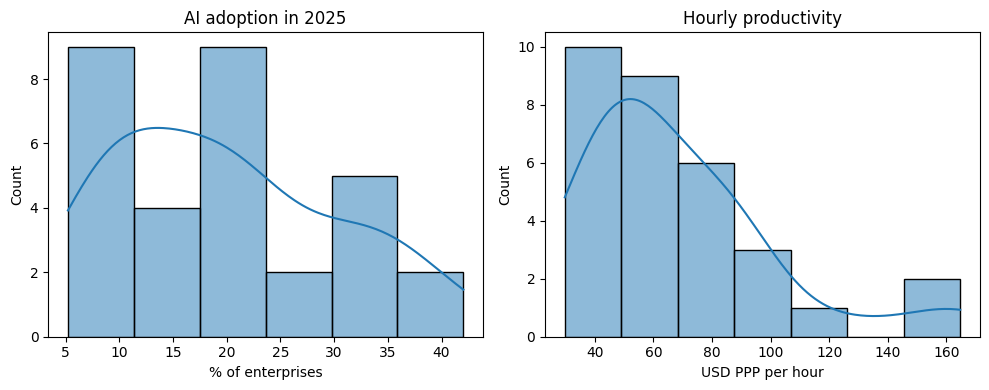

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df['ai_adoption_2025'], ax=axes[0], kde=True)
axes[0].set_title("AI adoption in 2025")
axes[0].set_xlabel("% of enterprises")

sns.histplot(df['hourly_productivity'], ax=axes[1], kde=True)
axes[1].set_title("Hourly productivity")
axes[1].set_xlabel("USD PPP per hour")

plt.tight_layout()
plt.show()

Both distributions are right-skewed: most countries have moderate AI adoption and productivity, with a minority of countries (Denmark, Finland, Ireland, Luxembourg) clearly above the rest. This is consistent with what we know about the European economy — a small group of Nordic countries and economic "hubs" (often linked to the presence of multinationals) pull the averages upward.

### 2.2. The central relationship: AI adoption and productivity

This is the most important chart in this section: it directly visualizes our research question.

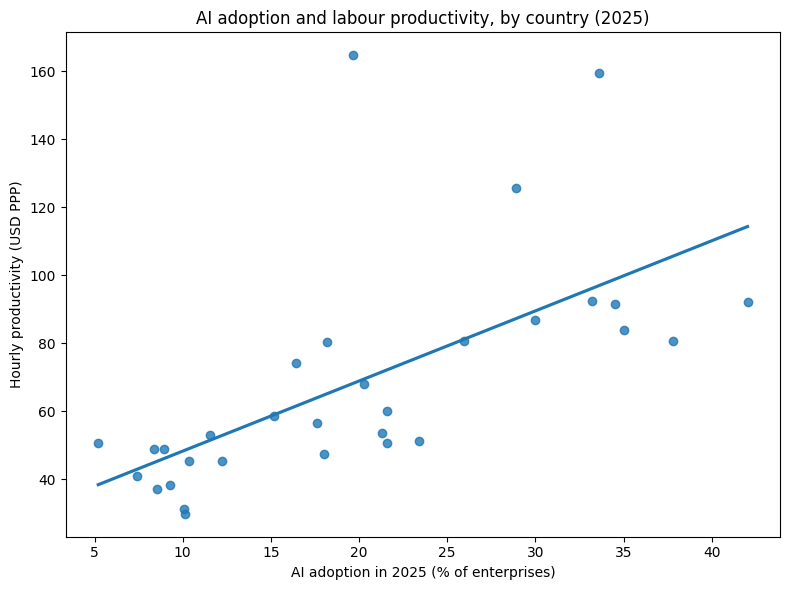

Correlation coefficient: r = 0.640


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(x='ai_adoption_2025', y='hourly_productivity', data=df, ax=ax, ci=None)
ax.set_xlabel("AI adoption in 2025 (% of enterprises)")
ax.set_ylabel("Hourly productivity (USD PPP)")
ax.set_title("AI adoption and labour productivity, by country (2025)")
plt.tight_layout()
plt.show()

correlation = df['ai_adoption_2025'].corr(df['hourly_productivity'])
print(f"Correlation coefficient: r = {correlation:.3f}")

We observe a moderate positive correlation (r ≈ 0.64) between AI adoption and hourly productivity. Countries like Denmark, Finland, and Sweden combine high AI adoption with strong productivity, while Romania, Bulgaria, and Poland sit at the opposite end on both variables.

But two countries clearly stand out from the cloud of points: Ireland and Luxembourg show very high productivity (over 150 USD/hour) without having the highest AI adoption. This is not a statistical anomaly — it is a well-documented economic fact: the productivity of these two countries is inflated by the presence of multinational headquarters that book their intellectual property there, without this reflecting the "real" productivity of their local workforce.

This observation matters: it suggests that part of the observed relationship could be driven by structural factors (wealth, presence of multinationals) rather than a direct effect of AI. This is exactly what we check next with the multiple regression.

### 2.3. The risk of omitted variable bias: the role of GDP per capita

Before drawing any conclusion, we check whether a third variable — a country's wealth — could explain both AI adoption and productivity.

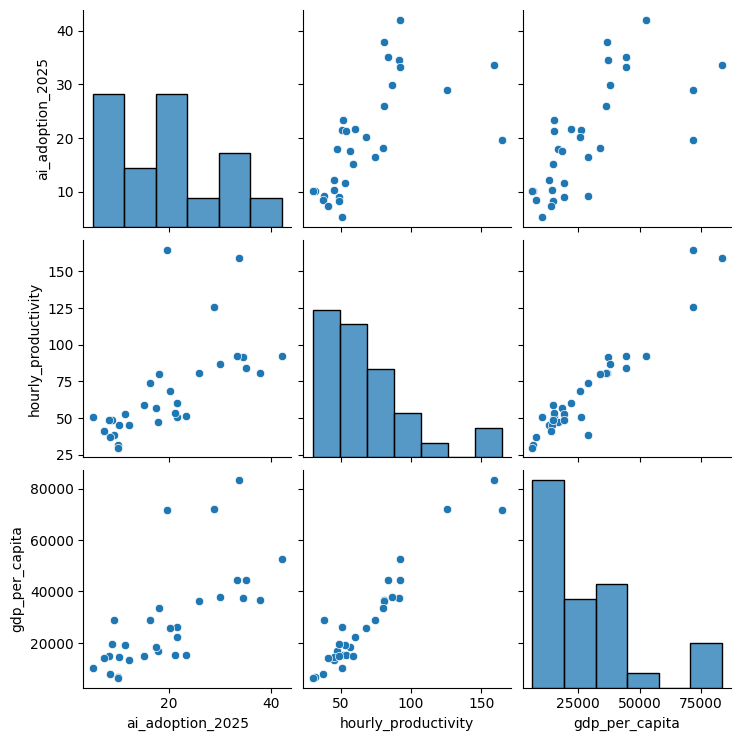

In [7]:
vars_of_interest = ['ai_adoption_2025', 'hourly_productivity', 'gdp_per_capita']
sns.pairplot(df[vars_of_interest])
plt.show()

In [8]:
correlations = df[vars_of_interest].corr().round(3)
correlations

,ai_adoption_2025,hourly_productivity,gdp_per_capita
ai_adoption_2025,1.000,0.640,0.696
hourly_productivity,0.640,1.000,0.954
gdp_per_capita,0.696,0.954,1.000


The finding is clear, and it is the most important point of the EDA: GDP per capita is **strongly correlated** with both productivity (r ≈ 0.95) and AI adoption (r ≈ 0.70).

In other words, richer countries have both better productivity AND higher AI adoption — but we don't yet know whether AI genuinely contributes to productivity, or whether both are simply symptoms of a country's wealth. This is the classic problem of **omitted variable bias** in econometrics, and it is exactly what a multiple regression with a control variable can help disentangle.

## 3. Hypothesis test: do high-AI-adoption countries have different productivity?

Before moving to regression, we ask a simpler, more direct question with a t-test: if we split countries into two groups based on their AI adoption level (above or below the median), does their average productivity differ in a statistically significant way?

**H0:** average productivity is the same in the high-adoption group and the low-adoption group.
**Ha:** average productivity differs between the two groups.


In [9]:
median_adoption = df['ai_adoption_2025'].median()

high_group = df[df['ai_adoption_2025'] >= median_adoption]['hourly_productivity']
low_group = df[df['ai_adoption_2025'] < median_adoption]['hourly_productivity']

print(f"Median AI adoption: {median_adoption:.2f} %")
print(f"High adoption group (n={len(high_group)}): mean productivity = {high_group.mean():.2f}")
print(f"Low adoption group (n={len(low_group)}): mean productivity = {low_group.mean():.2f}")

Median AI adoption: 18.16 %
High adoption group (n=16): mean productivity = 88.83
Low adoption group (n=15): mean productivity = 47.06


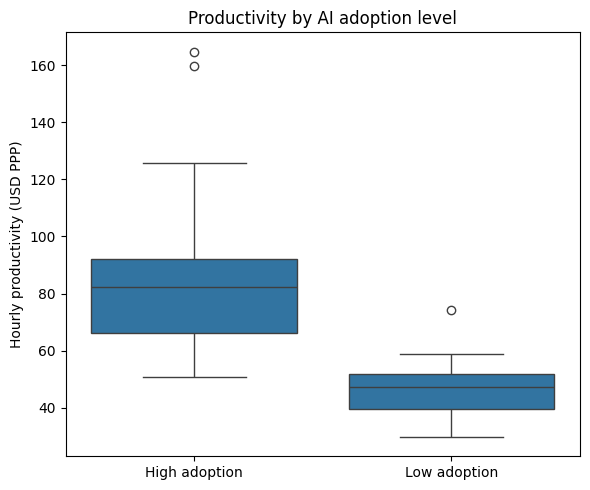

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
df['adoption_group'] = np.where(df['ai_adoption_2025'] >= median_adoption, 'High adoption', 'Low adoption')
sns.boxplot(x='adoption_group', y='hourly_productivity', data=df, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Hourly productivity (USD PPP)")
ax.set_title("Productivity by AI adoption level")
plt.tight_layout()
plt.show()

In [11]:
# Welch's t-test: we do not assume equal variances across groups,
# a reasonable precaution with such a small sample (31 countries)
t_stat, p_value = stats.ttest_ind(high_group, low_group, equal_var=False)
print(f"t-statistic = {t_stat:.3f}")
print(f"P-value = {p_value:.4f}")

t-statistic = 4.601
P-value = 0.0002


The p-value (0.0002) is well below the 0.05 threshold: we reject H0. Countries with high AI adoption have significantly higher productivity than countries with low adoption — a difference of more than 40 USD per hour between the two groups.

**A note on interpretation:** this test confirms a statistically significant difference, but says nothing about the *cause* of that difference. As seen in the EDA, these same high-AI-adoption countries are also the wealthiest. The multiple regression below will check whether AI keeps a distinct effect once we control for that wealth.

## 4. Simple regression: quantifying the relationship

The previous test confirms a difference between groups, but a linear regression lets us go further: quantifying *how much* productivity increases for each additional point of AI adoption, and measuring the share of total variation that this single variable explains.


In [12]:
simple_model = ols('hourly_productivity ~ ai_adoption_2025', data=df).fit()
print(simple_model.summary())

                             OLS Regression Results                            
Dep. Variable:     hourly_productivity   R-squared:                       0.410
Model:                             OLS   Adj. R-squared:                  0.390
Method:                  Least Squares   F-statistic:                     20.17
Date:                 Wed, 17 Jun 2026   Prob (F-statistic):           0.000104
Time:                         12:03:37   Log-Likelihood:                -143.85
No. Observations:                   31   AIC:                             291.7
Df Residuals:                       29   BIC:                             294.6
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           27.6146   

**Interpretation:**

- **R² = 0.410**: AI adoption explains 41% of the variation in productivity across countries. This is a notable result for a single variable in social science.
- **Coefficient = 2.06**: each additional percentage point of AI adoption is associated with a 2.06 USD increase in hourly productivity, on average.
- **P-value < 0.001**: this coefficient is statistically highly significant.

Taken in isolation, this result seems to confirm the hypothesis of a strong link between AI and productivity. But we already know, from the EDA, that a hidden variable — GDP per capita — could explain much of this relationship. This is what we test now.

## 5. Multiple regression: does the AI effect survive controlling for wealth?

We add GDP per capita as a control variable. The goal: isolate the distinct effect of AI adoption on productivity, *all else equal* — that is, after neutralizing the effect of the country's overall wealth.


In [13]:
multiple_model = ols('hourly_productivity ~ ai_adoption_2025 + gdp_per_capita', data=df).fit()
print(multiple_model.summary())

                             OLS Regression Results                            
Dep. Variable:     hourly_productivity   R-squared:                       0.911
Model:                             OLS   Adj. R-squared:                  0.905
Method:                  Least Squares   F-statistic:                     144.2
Date:                 Wed, 17 Jun 2026   Prob (F-statistic):           1.81e-15
Time:                         12:03:37   Log-Likelihood:                -114.46
No. Observations:                   31   AIC:                             234.9
Df Residuals:                       28   BIC:                             239.2
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           23.9445   

**This is the central result of this project, and it is unambiguous:**

- **R² = 0.911**: both variables together explain 91% of the variation in productivity — a sharp improvement over the simple regression (41%).
- **Coefficient of `gdp_per_capita` = 0.0017, p < 0.001**: highly significant. GDP per capita is a powerful predictor of productivity (which makes sense: both measure closely related aspects of economic wealth).
- **Coefficient of `ai_adoption_2025` = -0.145, p = 0.569**: **not significant**. Once we control for GDP per capita, AI adoption no longer has a statistically distinct effect on productivity — the coefficient even turns slightly negative, which is more a sign of statistical noise than a genuine effect.

**What this means economically:** the relationship observed in the simple regression between AI and productivity does not reflect a distinct effect of AI, but largely the fact that richer countries both adopt AI more and are more productive for other reasons (infrastructure, education, institutions, presence of multinationals). This is a concrete example of **omitted variable bias**: ignoring GDP per capita in the simple regression overstated the apparent effect of AI.

## 6. Checking the model's assumptions

Before trusting these results, we check that the multiple regression model satisfies its basic assumptions. With only 31 observations, these checks matter even more.


### 6.1. Normality of residuals

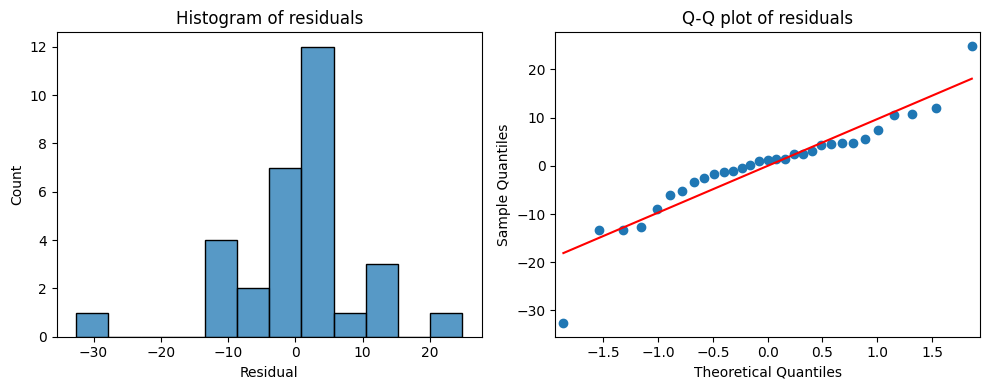

In [14]:
residuals = multiple_model.resid

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(residuals, ax=axes[0])
axes[0].set_title("Histogram of residuals")
axes[0].set_xlabel("Residual")

sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("Q-Q plot of residuals")

plt.tight_layout()
plt.show()

The histogram is roughly centred on 0 but somewhat skewed, and the Q-Q plot shows a notable departure at the left tail (one country whose residual is much more negative than expected — likely a small Eastern European country where the model overestimates productivity). With a sample of only 31 countries, this kind of single outlier carries relatively more weight. Normality is reasonable, though not perfect.

### 6.2. Homoscedasticity (constant variance of residuals)

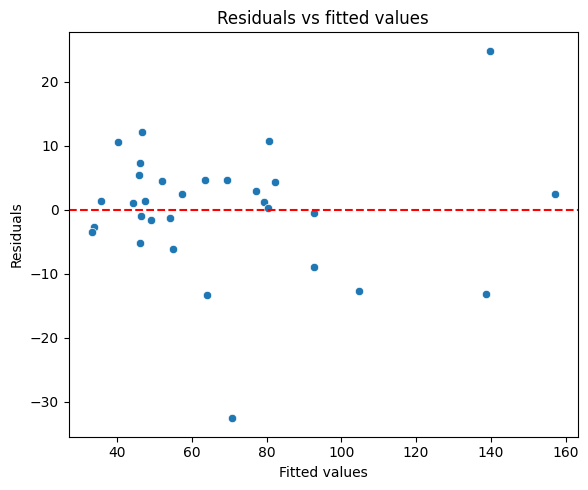

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(x=multiple_model.fittedvalues, y=multiple_model.resid, ax=ax)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs fitted values")
plt.tight_layout()
plt.show()

The spread of residuals is reasonably stable along the range of fitted values, without a marked funnel shape. The homoscedasticity assumption appears broadly satisfied, with the same outlier already noted in the Q-Q plot.

### 6.3. Multicollinearity (VIF)

This is the most important assumption to check here, since we already know from the EDA that AI adoption and GDP per capita are correlated with each other (r ≈ 0.70).

In [16]:
X = df[['ai_adoption_2025', 'gdp_per_capita']]
vif_values = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df = pd.DataFrame({'variable': X.columns, 'VIF': vif_values})
vif_df

,variable,VIF
0,ai_adoption_2025,6.140785
1,gdp_per_capita,6.140785


A VIF of 6.1 for both variables indicates notable multicollinearity (above the cautious threshold of 5, but below the critical threshold of 10). This is not surprising: it is the direct, expected consequence of wealthier countries adopting AI more.

**This multicollinearity does not undermine the main conclusion — if anything, it explains it.** The AI adoption coefficient is not significant precisely *because* this variable carries information very close to that of GDP per capita once both are included together. This is consistent with our interpretation: AI adoption and a country's wealth largely tell the same statistical story.

## 7. Conclusion of the main analysis

**Answer to the research question:** in this sample of 31 European countries, we find no robust evidence of a distinct effect of AI adoption on labour productivity once we control for a country's level of wealth.

### What we can say

- There is indeed a significant simple correlation between AI adoption and productivity (r ≈ 0.64).
- But this correlation collapses statistically as soon as GDP per capita is added as a control variable: the AI coefficient becomes non-significant (p = 0.57), while GDP per capita explains most of the variation in productivity (R² rises from 0.41 to 0.91).
- The multicollinearity diagnostic (VIF ≈ 6.1) confirms that AI adoption and a country's wealth carry largely the same statistical information in this sample.

### What we can NOT say

- We cannot conclude that "AI has no effect on productivity" — absence of evidence is not evidence of absence. With only 31 observations, the model has limited statistical power to detect a modest AI effect if one truly exists.
- We also cannot establish causality in either direction. It is just as plausible that wealthier countries have more resources to invest in AI (reverse causality) as the other way around.
- The European sample does not allow us to generalize these results to the global economy.

### Why this result is useful

This project illustrates a central methodological point in applied economics: a correlation that seems to confirm an intuitive hypothesis ("AI boosts productivity") may actually reflect a deeper confounding factor. This is exactly the kind of caution expected from rigorous economic analysis — and what distinguishes descriptive statistics from genuine econometric inference.

### Directions for further research

- Use panel data (several years per country) rather than a cross-section at a single point in time, which would better isolate AI's effect over time.
- Break down AI adoption by economic sector rather than at the aggregate country level, to see whether the effect differs across sectors (for example, in information-intensive services versus manufacturing).
- Extend the sample beyond Europe (OECD, Canada, United States) to test the robustness of the result in a different context.


## 8. Going further: adoption growth rather than level

The previous conclusion relies on the *level* of AI adoption in 2025. But one limitation already identified is that this is a single snapshot — it captures no dynamics at all.

We have an additional variable in the dataset: the **growth of AI adoption between 2024 and 2025**, in percentage points (`ai_adoption_growth_pp`). This is another way of framing the question: not "are countries that use AI the most today more productive?", but rather "are countries where AI adoption is growing fastest more productive?". If AI had a real, recent causal effect on productivity, we might expect this adoption dynamic to be a more relevant signal than a simple level, which depends heavily on a country's economic history.


In [17]:
growth_model = ols('hourly_productivity ~ ai_adoption_growth_pp', data=df).fit()
print(growth_model.summary())

                             OLS Regression Results                            
Dep. Variable:     hourly_productivity   R-squared:                       0.238
Model:                             OLS   Adj. R-squared:                  0.212
Method:                  Least Squares   F-statistic:                     9.057
Date:                 Wed, 17 Jun 2026   Prob (F-statistic):            0.00537
Time:                         12:03:37   Log-Likelihood:                -147.83
No. Observations:                   31   AIC:                             299.7
Df Residuals:                       29   BIC:                             302.5
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept           

Taken alone, this model is weaker than the one based on the level (R² = 0.24 versus 0.41), but remains statistically significant (p = 0.005). The decisive question remains the same: does this effect survive controlling for GDP per capita?

In [18]:
growth_gdp_corr = df['ai_adoption_growth_pp'].corr(df['gdp_per_capita'])
print(f"Correlation between AI adoption growth and GDP per capita: {growth_gdp_corr:.3f}")

multiple_growth_model = ols('hourly_productivity ~ ai_adoption_growth_pp + gdp_per_capita', data=df).fit()
print(multiple_growth_model.summary())

Correlation between AI adoption growth and GDP per capita: 0.501
                             OLS Regression Results                            
Dep. Variable:     hourly_productivity   R-squared:                       0.911
Model:                             OLS   Adj. R-squared:                  0.904
Method:                  Least Squares   F-statistic:                     142.6
Date:                 Wed, 17 Jun 2026   Prob (F-statistic):           2.09e-15
Time:                         12:03:37   Log-Likelihood:                -114.62
No. Observations:                   31   AIC:                             235.2
Df Residuals:                       28   BIC:                             239.5
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

In [19]:
X = df[['ai_adoption_growth_pp', 'gdp_per_capita']]
vif_values = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
pd.DataFrame({'variable': X.columns, 'VIF': vif_values})

,variable,VIF
0,ai_adoption_growth_pp,3.557184
1,gdp_per_capita,3.557184


**This result reinforces the main conclusion rather than contradicting it.**

Even when changing the angle — testing the dynamics of adoption rather than its level — the finding is identical: once GDP per capita is taken into account, growth in AI adoption no longer has a statistically significant effect on productivity (p = 0.839).

One notable technical detail: the VIF here is lower (3.6 versus 6.1 in the level model), meaning multicollinearity between this variable and GDP per capita is less extreme. Yet the conclusion remains the same. This suggests that the non-significance of AI is not merely a collinearity artifact, but a more robust result: whether we look at the level of AI adoption or its recent growth, we find no detectable distinct effect on productivity once a country's wealth is accounted for.

## 9. Going further: a typology of countries through clustering (K-Means)

The previous sections answer a causal-type question: does AI have an effect on productivity? The nuanced answer is no — not once wealth is controlled for. But we can ask a different, descriptive rather than causal, question: **are there distinct country profiles** that combine AI adoption, productivity, and wealth differently?

This is a legitimate question for K-Means, because we are not asking it to establish causality — only to group together countries that resemble each other along these three dimensions. We use the three variables already central to the analysis: AI adoption in 2025, hourly productivity, and GDP per capita, all standardized so that each carries equal weight in the distance calculation.


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_vars = ['ai_adoption_2025', 'hourly_productivity', 'gdp_per_capita']
X = df[cluster_vars].copy()
X_scaled = StandardScaler().fit_transform(X)

### 9.1. Choosing the number of clusters

We test several values of k using the elbow method (inertia) and the silhouette score, to choose a number of groups that is both statistically justified and interpretable — with only 31 countries, we avoid looking for too many groups.

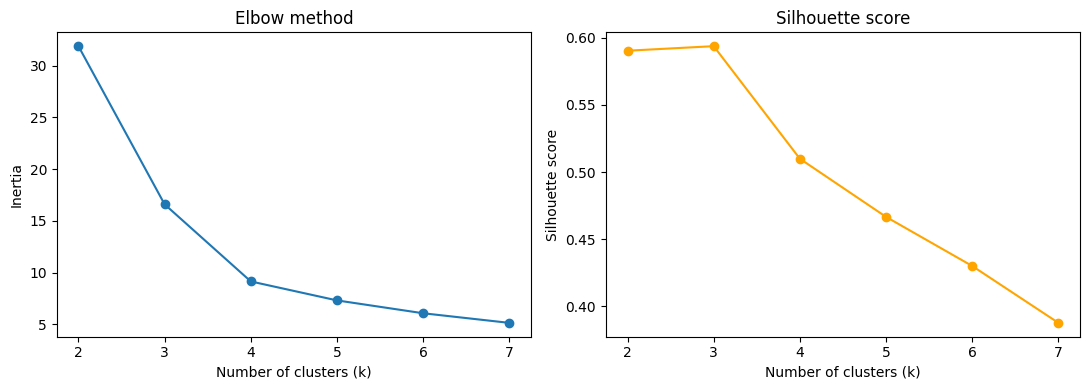

In [21]:
inertias, sil_scores = [], []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')

axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score')
plt.tight_layout()
plt.show()

The silhouette score is maximal at **k=3** (0.594), while staying close to k=2. The elbow method also shows a clear inflection after k=3. We therefore retain 3 groups — a choice that remains interpretable for a sample of this size.

### 9.2. The three country profiles

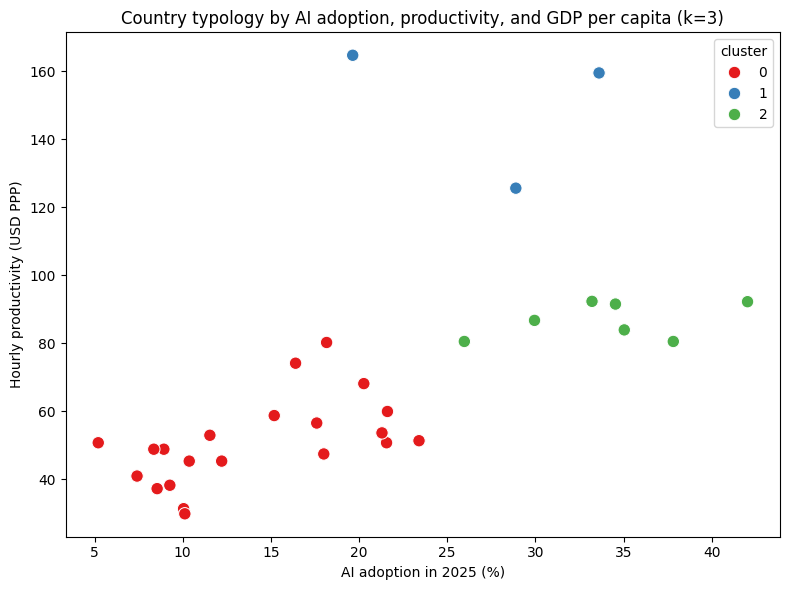

In [22]:
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = final_kmeans.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='ai_adoption_2025', y='hourly_productivity', hue='cluster',
                 palette='Set1', data=df, s=80, ax=ax)
ax.set_xlabel("AI adoption in 2025 (%)")
ax.set_ylabel("Hourly productivity (USD PPP)")
ax.set_title("Country typology by AI adoption, productivity, and GDP per capita (k=3)")
plt.tight_layout()
plt.show()

In [23]:
df.groupby('cluster')[cluster_vars].mean().round(1)

,ai_adoption_2025,hourly_productivity,gdp_per_capita
cluster,,,
0,14.1,50.9,17773.3
1,27.4,149.9,75630.0
2,34.1,86.8,41405.7


In [24]:
for c in sorted(df['cluster'].unique()):
    cluster_countries = df[df['cluster'] == c]['country'].tolist()
    print(f"Cluster {c} (n={len(cluster_countries)}): {', '.join(cluster_countries)}")
    print()

Cluster 0 (n=21): Estonia, Slovenia, Malta, Lithuania, Spain, France, Slovakia, Czechia, Italy, Croatia, Latvia, Portugal, Hungary, Cyprus, Greece, Bulgaria, Poland, Romania, Montenegro, Serbia, Turkiye

Cluster 1 (n=3): Luxembourg, Ireland, Norway

Cluster 2 (n=7): Denmark, Finland, Sweden, Belgium, Netherlands, Austria, Germany



**Three economic profiles emerge clearly:**

- **Cluster 0 — Central, Eastern, and Mediterranean Europe (n=21)**: moderate AI adoption (14% on average), lower productivity and GDP per capita. This is the largest group, covering most countries in the sample — from Poland to Portugal, including Greece and Romania.

- **Cluster 1 — Multinational hubs (n=3)**: Luxembourg, Ireland, and Norway. These are precisely the three countries flagged as outliers in the EDA from the very start. Their productivity is exceptionally high (149.9 on average) without their AI adoption being the highest — a signal consistent with the structural explanation already raised (presence of multinationals, oil sector for Norway, accounting effects linked to intellectual property).

- **Cluster 2 — Northern Europe and advanced digital economies (n=7)**: Denmark, Finland, Sweden, Belgium, Netherlands, Austria, Germany. This is the group with the highest AI adoption (34% on average) and solid productivity, without reaching the extreme levels of the multinational-hub cluster.

**The link to the project's main conclusion:** this grouping confirms, through a completely different method, the central observation of the analysis. The cluster with the *highest* AI adoption (cluster 2, 34%) is not the one with the *highest* productivity — that is cluster 1 (multinational hubs, average AI adoption of only 27%), driven by structural factors that have nothing to do with AI. K-Means, with no causal assumptions whatsoever, traces the same story as the regression: a country's wealth and economic structure matter more than its level of AI adoption in explaining its productivity.

## 10. General conclusion

This project answers a simple question — is AI adoption linked to economic productivity? — through a progressive approach, where each step questions the one before it.

**What the analysis as a whole shows:**

1. A simple correlation does exist between AI adoption and productivity (r = 0.64), and a t-test confirms a significant productivity difference between high- and low-adoption countries.
2. But this relationship collapses statistically as soon as we control for GDP per capita: the AI coefficient becomes non-significant, while a country's wealth explains most of the variation (R² = 0.91).
3. This result is not an artifact of how AI adoption is measured: whether we use the *level* of adoption in 2025 or its recent *growth* (2024-2025), the conclusion stays the same once wealth is accounted for — with even lower multicollinearity for the growth variable, which reinforces the robustness of the finding.
4. A completely different approach, K-Means clustering, produces three country profiles with no causal assumptions at all — and these profiles tell the same story: the most productive group (multinational hubs like Ireland and Luxembourg) is not the one that adopts AI the most.

**The overall conclusion** is therefore that, with the data available at this stage, we find no robust evidence of a distinct effect of AI on macroeconomic productivity in Europe — most of what we observe as a simple correlation reflects countries' structural wealth rather than a specific effect of the technology. This is a result worth taking seriously at a time when AI is often presented as an immediate and automatic driver of economic transformation: the data available today, at the macro level and on a limited sample, does not allow us to confirm this intuition as simply as one might think.

This does not mean AI has no effect — only that any such effect, if it exists, is more subtle than a simple cross-country comparison can reveal, and that finer-grained data (panel data, sector-level, or firm-level rather than country-level) will be needed to detect it with greater confidence.
